In [27]:
import pandas as pd
import seaborn as sns
true = pd.read_csv('data/True.csv')
false = pd.read_csv('data/Fake.csv')
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,31/12/17
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,29/12/17
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,31/12/17
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,30/12/17
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,29/12/17


In [28]:
true.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [29]:
false.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [30]:
true['label'] = 1
false['label'] = 0
frames = [true.loc[:][:], false.loc[:][:]]
df = pd.concat(frames)
df.tail()

,title,text,subject,date,label
23445,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,16/1/16,0
23446,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,16/1/16,0
23447,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,15/1/16,0
23448,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,14/1/16,0
23449,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,12/1/16,0


In [31]:
true['label'] = 1
false['label'] = 0
frames = [true.loc[:][:], false.loc[:][:]]
df = pd.concat(frames)
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,31/12/17,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,29/12/17,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,31/12/17,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,30/12/17,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,29/12/17,1


<Axes: xlabel='label', ylabel='count'>

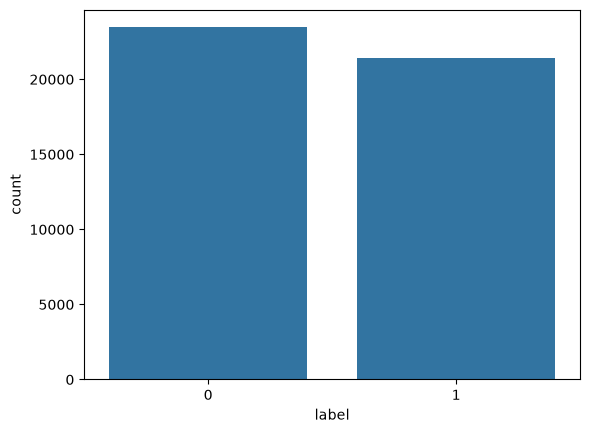

In [32]:
sns.countplot(data = df, x='label')

C:\Users\nda\AppData\Local\Temp\ipykernel_44856\692215410.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df["date"], errors="coerce")


<Axes: xlabel='Year', ylabel='count'>

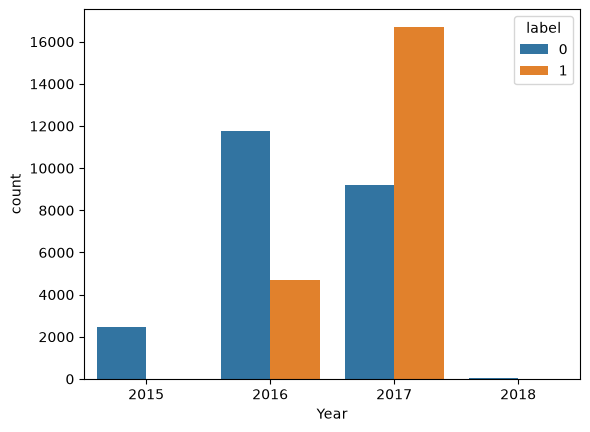

In [33]:
df['date'] = pd.to_datetime(df["date"], errors="coerce")
df["Year"] = df["date"].dt.year 
df["Month"] = df["date"].dt.month 
sns.countplot(data = df, x = "Year", hue = "label")

<Axes: xlabel='Month', ylabel='count'>

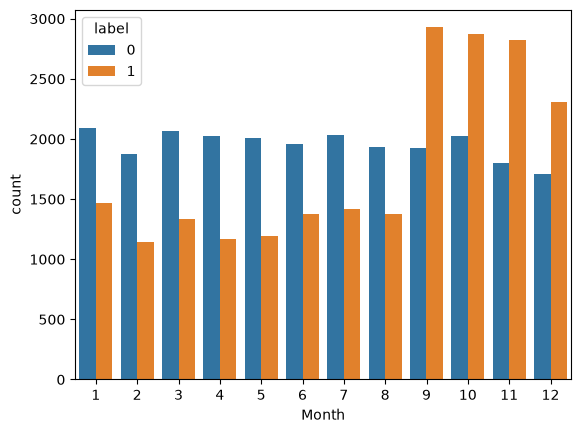

In [34]:
df['date'] = pd.to_datetime(df["date"], errors="coerce")
df["Year"] = df["date"].dt.year 
df["Month"] = df["date"].dt.month 
sns.countplot(data = df, x = "Month", hue = "label")

In [35]:
df.subject.value_counts()

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6833
left-news           4454
Government News     1568
US_News              775
Middle-east          770
Name: count, dtype: int64

<Axes: xlabel='Year', ylabel='count'>

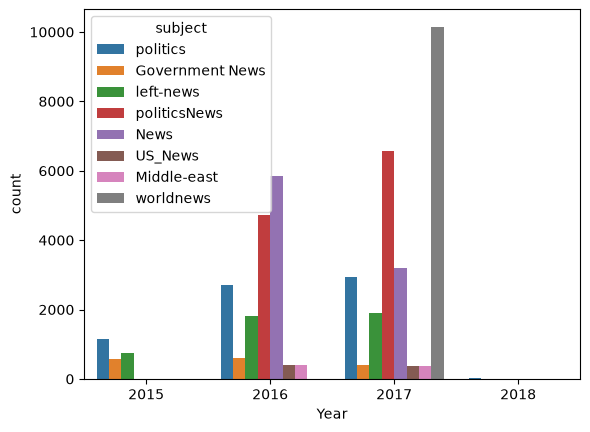

In [36]:
sns.countplot(data = df, x="Year", hue="subject")

In [37]:
frames = [true.head(200), false.head(200)]
df = pd.concat(frames)
X = df.drop('label', axis=1)
y = df['label']
df.label.value_counts()
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,31/12/17,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,29/12/17,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,31/12/17,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,30/12/17,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,29/12/17,1


In [38]:
df = df.dropna()
df2 = df.copy()
df2.reset_index(inplace = True)
df2.tail

<bound method NDFrame.tail of      index                                              title  \
0        0  As U.S. budget fight looms, Republicans flip t...   
1        1  U.S. military to accept transgender recruits o...   
2        2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3        3  FBI Russia probe helped by Australian diplomat...   
4        4  Trump wants Postal Service to charge 'much mor...   
..     ...                                                ...   
395    195   Nursing Textbooks Recalled And Apology Issued...   
396    196   Trump SCREAMS On Twitter After Seeing A Poll ...   
397    197   Trump And John Kelly Just Got RIPPED APART By...   
398    198   NRA Releases Fascist Ad Calling All Trump Cri...   
399    199   Trump Takes Credit For Releasing JFK Files, B...   

                                                  text       subject  \
0    WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1    WASHINGTON (Reuters) - Transgender peopl

In [39]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re
import nltk

nltk.download('stopwords')
ps = PorterStemmer()
corpus = []
for i in range(0, len(df2)):
    review = re.sub('[^a-zA-Z]', ' ', df2['text'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word 
	in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


KeyboardInterrupt: 

In [ ]:
print(corpus)

['washington reuter head conserv republican faction u congress vote month huge expans nation debt pay tax cut call fiscal conserv sunday urg budget restraint keep sharp pivot way among republican u repres mark meadow speak cb face nation drew hard line feder spend lawmak brace battl januari return holiday wednesday lawmak begin tri pass feder budget fight like link issu immigr polici even novemb congression elect campaign approach republican seek keep control congress presid donald trump republican want big budget increas militari spend democrat also want proport increas non defens discretionari spend program support educ scientif research infrastructur public health environment protect trump administr alreadi will say go increas non defens discretionari spend percent meadow chairman small influenti hous freedom caucu said program democrat say enough need give govern pay rais percent fiscal conserv see rational eventu run peopl money said meadow among republican vote late decemb parti 

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_v = TfidfVectorizer()
X = tfidf_v.fit_transform(corpus).toarray()
y = df2['label']
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(348, 7662))

In [47]:
print("X shape:", X.shape)
print("y length:", len(y))


X shape: (348, 7662)
y length: 400


In [48]:
from sklearn.model_selection import train_test_split
# Force 'y' to match the exact same number of rows as 'X'
y = y.iloc[:X.shape[0]]

# Now your original line will run perfectly!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
classifier = LogisticRegression()
classifier.fit(X_train, y_train)
pred = classifier.predict(X_test)
score = metrics.accuracy_score(y_test, pred)
print("accuracy : %0.3f" % score)

accuracy : 0.986


Text(0.5, 1.0, 'Confusion Matrix')

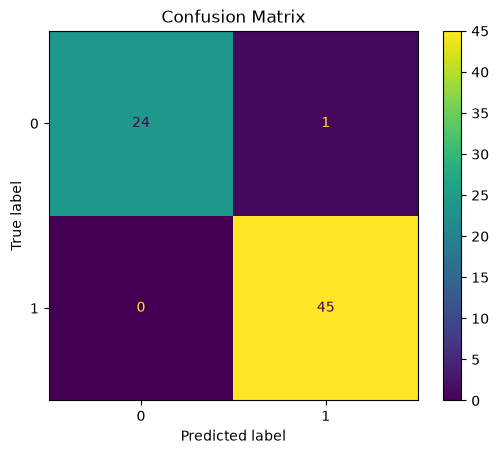

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)
disp.ax_.set_title("Confusion Matrix")

In [54]:
import pickle
pickle.dump(classifier, open('model2.pkl','wb'))
pickle.dump(tfidf_v, open('tfidfvect2.pkl','wb'))

In [55]:
model = pickle.load(open('model2.pkl', 'rb'))
tfidfvect2 = pickle.load(open('tfidfvect2.pkl', 'rb'))

In [56]:
def predict(text):
    review = re.sub('[^a-zA-Z]','',text)
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ''.join(review)
    review_vect = tfidfvect2.transform([review]).toarray()
    prediction = 'FAKE' if model.predict(review_vect) == 0 else 'REAL'
    return prediction

In [61]:
text = "Trump Says He’s Done More Than Any President Ever"
prediction = predict(text)
print(prediction)

FAKE
